## Capytaine Demo Script

For any script in python, you must first import packages

In [304]:
import numpy as np
import capytaine as cpt
import xarray as xr
import matplotlib.pyplot as plt

Next, load in a pre-defined geometry and mesh using Capytaine tools. 

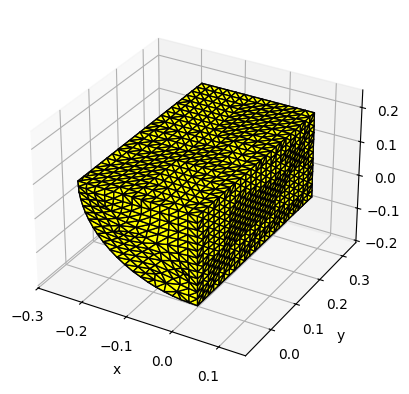

In [354]:
# Path to Custom STL File
stl_path = "/Users/zach/Desktop/MechaCapstone/CapytaineAnalysis/orientedfloat.stl"

# Generate the Mesh from STL File
mesh = cpt.load_mesh(stl_path, file_format="stl")

# Geometry and Properties of the Body
R = 0.254 # Radius [m]
L = 0.4572 # Length [m]
h = 0.146003 # Height Outside of Water [m]
m = 5 # Mass [kg]
xbar = (4*R)/3/np.pi  # Centroid of Quarter Sphere [m]

# Transform the Mesh into Correct Orientation
mesh = mesh.rotated_z(np.pi)
mesh = mesh.translated_z(0.019) 
mesh = mesh.translated_x(-0.075)
mesh = mesh.translated_y(0.13)

# Show the Mesh
mesh.show_matplotlib()


A floating body object must be created in order to run the diffraction and radiation simulations in Capytaine. This includes defining the center of rotation of your body for the calculation of the rotation degrees of freedom. Using dofs = cpy.rigid_body_dofs() will automatically define all six rigid body degrees of freedom at the center of rotation selected. If center of rotation is not defined, it will default to the waterline (0,0,0), if center of rotation is not set and center of mass is set, it will default to calculation about the center of mass. The mass and center of mass values are used in hydrostatics calculations, and if not set, will default to those calculated based on the mesh.

The mass and center of mass values are not needed for the diffraction and radiation problems. Only for hydrostatics.

If you desire BEM values calculated about a different location, change the rotation center to reflect this.

If you have multiple bodies, they must have distinct names

In [355]:
# Define Floating Body

fb = cpt.FloatingBody(
    mesh=mesh, 
    dofs=cpt.rigid_body_dofs(rotation_center=(-xbar, L/2, h-xbar)), 
    center_of_mass=(-xbar, L/2, h-xbar), 
    mass=m, 
    name="float"
)

In [366]:
# Hydrostatics
hydrostatics = fb.compute_hydrostatics()
print("Center of Mass: ", fb.center_of_mass, "m")
print("Center of Buoyancy: ", fb.center_of_buoyancy, "m")
print("Displaced Volume: ", hydrostatics["disp_volume"], "m^3")

Center of Mass:  [-0.10780095  0.2286      0.03820205] m
Center of Buoyancy:  [-0.05265482  0.12999865  0.04134272] m
Displaced Volume:  0.006881830646068488 m^3


Next, you need to define the parameters of your problem. 
- Period: The wave frequencies or periods need to be defined, which can be done by passing in omega (rad/s), periods, wavelengths, or wavenumbers in an array.
- Heading: The required wave directions are passed in with a list, in radians. 
- Density: Water density defaults to 1000 $kg/m^{3}$, but can be changed by passing in a value for rho.
- Depth: Water depth defaults to infinite, but can be changed by passing in a value in meters for water_depth. 
- Radiating DoFs: Finally, you need to assign your degrees of freedom as radiating to properly format for the radiation problem.

Additional options that can be changed are:
- Gravity
- Free-Surface location
- Forward Speed

In [377]:
frequencies = np.linspace(0.25, 5, 50)*2*np.pi
# You can pass in omega, period, wavelength, wavenumber
directions = 0 # Radians, default is 0 rad
depth = 2 
density = 1025 

solver = cpt.BEMSolver()
simulation_params = xr.Dataset(coords={
    'omega': frequencies,
    'wave_direction': directions,
    'radiating_dof': list(fb.dofs),
    'water_depth': depth,
    'rho': density,
})


/Users/zach/capytaine/venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

To actually run capytaine is a single line call, where you attach the simulation parameters and bem geometry to the solver. You only want to pass in the submerged portion of the mesh into the solver, so use the immersed_part() method to do this.

Other solver options include:
- njobs: when >1 parallel processing is used
- method: choose whether to solve directly or indirectly

In [378]:
bodies = [fb.immersed_part()]
bem_data = solver.fill_dataset(dataset=simulation_params, bodies=bodies)

[17:38:22] WARNING  Mesh resolution for 140 problems:                                                              
                    The resolution of the mesh might be insufficient for omega ranging from 19.843 to 31.416.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

           WARNING  Irregular frequencies for 210 problems:                                                        
                    Irregular frequencies might be encountered for omega ranging from 13.752 to 31.416.            
                    Setting a lid for the floating body is recommended.

Solving BEM problems ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:01:36

/Users/zach/capytaine/venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/zach/capytaine/venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

To format this data to be read into WEC-Sim using BEMIO, you need to convert it to a .nc file, and separate complex values so that they are stored properly

In [379]:
# Export to .nc file
ds = cpt.io.xarray.separate_complex_values(bem_data)
ds = ds.assign_coords(
    radiating_dof=ds.radiating_dof.astype(str),
    influenced_dof=ds.influenced_dof.astype(str),
)
ds.to_netcdf("hydroData.nc")

/Users/zach/capytaine/venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Let's look at the results! One way to view what's contained in this array is with bem_data.keys(), then try out some of these attributes and see what data it contains. There's more information about the shape of the dataset if you scroll down. You can index by name or value, if by value: [surge : 0, sway : 1, heave : 2, roll :3 , pitch : 4, yaw : 5]

Added Mass at 1 Hz:  8.007964065757847 kg

Radiation Damping at 1 Hz:  25.662496486457925 N-s/m

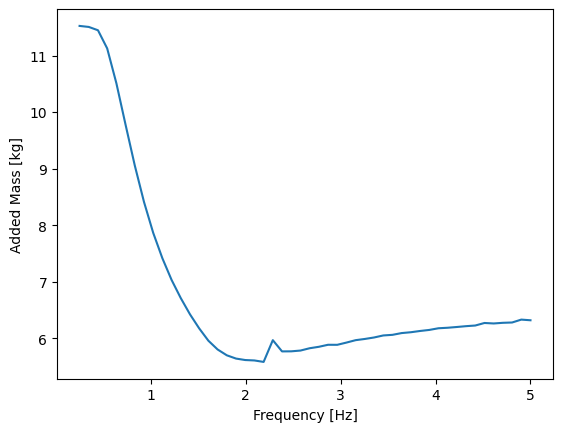

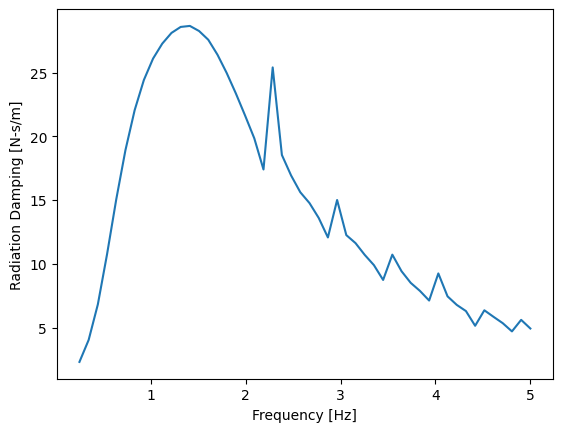

In [380]:
# Show Outputs in Heave Only
added_mass_hh = bem_data.added_mass[:,2,2]
freqs = bem_data.added_mass["omega"]
plt.figure()
plt.plot(freqs/(2*np.pi), added_mass_hh)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Added Mass [kg]")
radiation_damping_hh = bem_data.radiation_damping[:,2,2]
freqs = bem_data.radiation_damping["omega"]
plt.figure()
plt.plot(freqs/(2*np.pi), radiation_damping_hh)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Radiation Damping [N-s/m]")

print("Added Mass at 1 Hz: ", np.interp(1*2*np.pi, freqs, added_mass_hh), "kg")
#print("Added Mass at Infinite Hz: ", np.interp(50*2*np.pi, freqs, added_mass_hh), "kg")
print("Radiation Damping at 1 Hz: ", np.interp(1*2*np.pi, freqs, radiation_damping_hh), "N-s/m")

If you get the a warning about irregular frequencies, as seen in the wavebot example, you can now generate an internal lid to prevent this.

There are two options to use the generate_lid method on your mesh:
- Set the z-location of the lid manually
- Have Capytaine automatically choose lid location based on the maximum frequencies of your problem

In [369]:
# Irregular Frequencies
lid_mesh = mesh.generate_lid(z=0.12)
lid_mesh = mesh.generate_lid(z=mesh.lowest_lid_position(omega_max=frequencies.max()))

lidded_fb = cpt.FloatingBody(mesh=mesh, dofs=cpt.rigid_body_dofs(rotation_center=(-0.01061, 0.035/2, 0.0038)), mass=m, name="float1_lid")
lidded_data = solver.fill_dataset(dataset=simulation_params, bodies=lidded_fb.immersed_part())



[16:57:08] WARNING  Mesh resolution for 161 problems:                                                              
                    The resolution of the mesh might be insufficient for omega ranging from 19.747 to 34.558.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

           WARNING  Irregular frequencies for 224 problems:                                                        
                    Irregular frequencies might be encountered for omega ranging from 13.688 to 34.558.            
                    Setting a lid for the floating body is recommended.

KeyboardInterrupt: 

Text(0, 0.5, 'Radiation Damping [N-s/m]]')

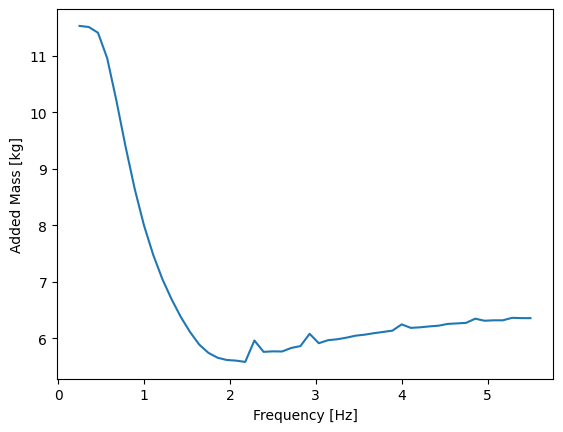

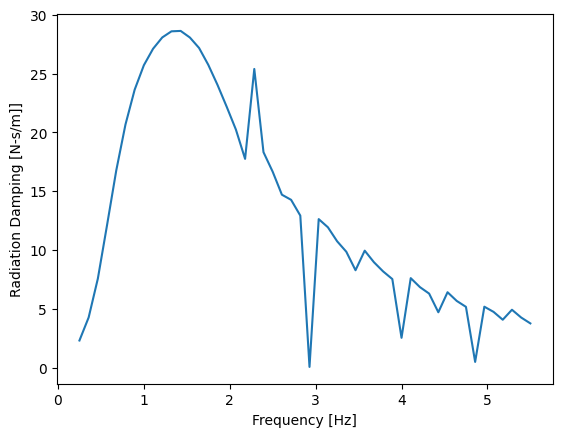

In [367]:
# Plot Lidded Results in Heave Only
plt.figure()
plt.plot(lidded_data.added_mass["omega"]/(2*np.pi), lidded_data.added_mass[:,2,2])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Added Mass [kg]")
plt.figure()
plt.plot(lidded_data.radiation_damping["omega"]/(2*np.pi), lidded_data.radiation_damping[:,2,2])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Radiation Damping [N-s/m]]")

This should remove the 'spikes' from the BEM data when compared to unlidded geometries.